# MedGemma-4b-pt smoke test

Goal: prove the whole stack works end-to-end — load `google/medgemma-4b-pt` on the Apple MPS
backend, embed one LIDC image through the model's SigLIP vision tower, and print the embedding
shape.

Run with the **Python (medgemma)** kernel. The model is gated — make sure `hf auth login`
has been done and the license at https://huggingface.co/google/medgemma-4b-pt is accepted.

## 1. Device + imports

In [1]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device, "| torch:", torch.__version__)

/Users/owenpacetti/Developer/research/code/wang/summer-26/med-gemma-embedding-research/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps | torch: 2.12.0


## 2. Load processor + model

First run downloads ~8 GB of weights to the HF cache — give it a few minutes. We load on CPU
then move to MPS (`device_map="auto"` is unreliable on Metal).

In [2]:
model_id = "google/medgemma-4b-pt"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=torch.bfloat16)
model = model.to(device).eval()
print(type(model).__name__, "loaded on", device)


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 883/883 [00:00<00:00, 21306.32it/s]

Gemma3ForConditionalGeneration loaded on mps


## 3. Load one LIDC image (grayscale → RGB)

The JPEGs are 71×71 grayscale; the processor resizes to the model's 896×896 input. We only need
to convert to 3-channel RGB.

image size: (71, 71) | mode: RGB


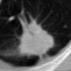

In [3]:
img = Image.open("../LIDC-images/1.jpg").convert("RGB")
print("image size:", img.size, "| mode:", img.mode)
img

## 4. Inspect the model's submodules

In transformers 5.x the multimodal pieces live under `model.model`: the SigLIP `vision_tower`,
the `multi_modal_projector`, and the `language_model`.

In [4]:
print("top-level submodules:", [name for name, _ in model.named_children()])
print("model.model submodules:", [name for name, _ in model.model.named_children()])
print("vision tower:", type(model.model.vision_tower).__name__)

top-level submodules: ['model', 'lm_head']
model.model submodules: ['vision_tower', 'multi_modal_projector', 'language_model']
vision tower: SiglipVisionModel


## 5. Extract an image embedding from the vision tower

For a pure image embedding we don't need any text, so we build `pixel_values` directly with the
processor's image processor (avoids the `<start_of_image>` text-token bookkeeping). We run the
image through the SigLIP vision tower and mean-pool the patch tokens into a single vector.

Expected: 4096 patch tokens × 1152 hidden dims → a 1152-d pooled embedding.

In [5]:
pixel_values = processor.image_processor(images=img, return_tensors="pt")["pixel_values"]
pixel_values = pixel_values.to(device).to(model.dtype)

with torch.no_grad():
    vision_out = model.model.vision_tower(pixel_values=pixel_values)

patch_embeds = vision_out.last_hidden_state          # (1, num_patches, hidden)
image_embedding = patch_embeds.mean(dim=1)           # (1, hidden) mean-pooled

print("pixel_values:", tuple(pixel_values.shape))
print("patch tokens:", tuple(patch_embeds.shape))
print("image embedding:", tuple(image_embedding.shape), "| dtype:", image_embedding.dtype)

pixel_values: (1, 3, 896, 896)
patch tokens: (1, 4096, 1152)
image embedding: (1, 1152) | dtype: torch.bfloat16
